In [34]:
# Import libraries
import numpy as np
from matplotlib import pylab as plt
from dopplerkernel import DopplerKernel

# 1. Initialize a DopplerKernel object
For a grid size $n$, the velocity field and weight function will be evaluated on an $n\times n$ grid.

In [36]:
# Create DopplerKernel object
dk = DopplerKernel(grid_size=100)

# 2. Create a velocity field 
**Parameters (see Appendix A in Wardenier et al. 2025):**

- Orbital phase $\phi \in [0,1)$, with $\phi = 0$ for transit and $\phi = 0.5$ for eclipse
- Rotational velocity at the equator $v_{\text{rot}}$ in km/s
- Source-to-sink flow speed $v_{\text{wind}}$ in km/s
- Sink longitude $\varphi_{\text{sink}}$ in degrees
- Jet speed at equator $v_{\text{jet}}$ in km/s
- Jet spatial width $\sigma_{\text{jet}}$ in units of $R_{\text{p}}$ 

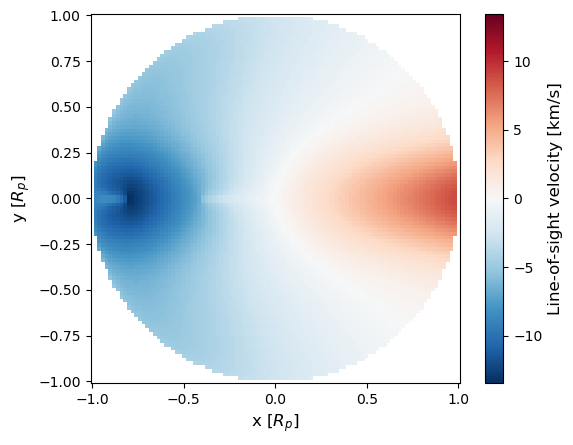

In [38]:
# Calculate the line-of-sight velocity field
dk.make_velocity_field(orbital_phase=0.35, v_rot=5, v_wind=4., sink_longitude=30., v_jet=8., sigma_jet=0.2)

# Plot the line-of-sight velocity field
dk.plot_velocity_map()

# 3. Create a weight mask 
**Parameters (see Appendix B in Wardenier et al. 2025):**

- Orbital phase $\phi \in [0,1)$, with $\phi = 0$ for transit and $\phi = 0.5$ for eclipse
- Weight $w_0$ of the disk center relative to the limb (the limb always has weight 1)
- nightside_zero: if True, the nightside will have zero weight

N.B. The mask will always be normalized (no matter the value of $w_0$). 

If `advanced_mask` is True, the function will consider three more parameters that are otherwise ignored:
- peak_shift_longitude $\varphi_{\text{peak}}$: shift of the weight peak relative to the substellar point (in degrees longitude)
- peak_shift_latitude $\theta_{\text{peak}}$: shift of the weight peak(s) relative to the substellar point (in degrees latitude)
- peak_dropoff $f_{\text{d}}$: strength of the peak dropoff towards the terminator ($f_{\text{d}} = 1$ for maximum dropoff and $f_{\text{d}} = 0$ for uniform weights) 

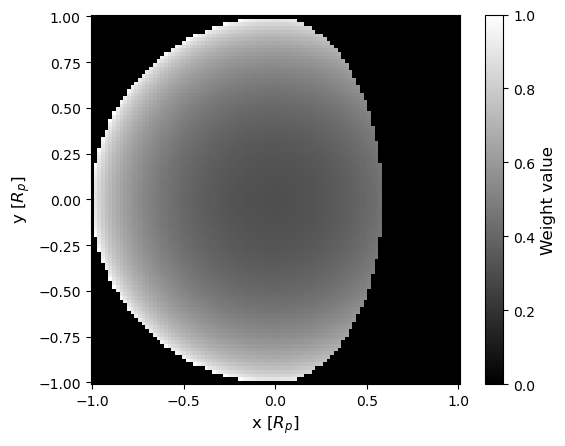

In [40]:
# Calculate the weight maks
dk.make_weight_mask(orbital_phase=0.35, w_0=0.3, peak_shift_longitude=0., peak_shift_latitude=80., 
                        peak_dropoff=1., nightside_zero=True, advanced_mask=False)

# Plot the weight mask
dk.plot_weight_mask()

# 4. Calculate the broadening kernel
Calculate the kernel based on the previously created line-of-sight velocity field and weight mask. Setting `calculate_x_y_arrays = True` will store the x and y values of the plot below in `dk.kernel_x_values` and `dk.kernel_y_values`.

N.B. Note that `calculate_doppler_kernel()` always assumes the most recently computed line-of-sight velocity field and weight mask. Just make sure these were created at the same orbital phase.

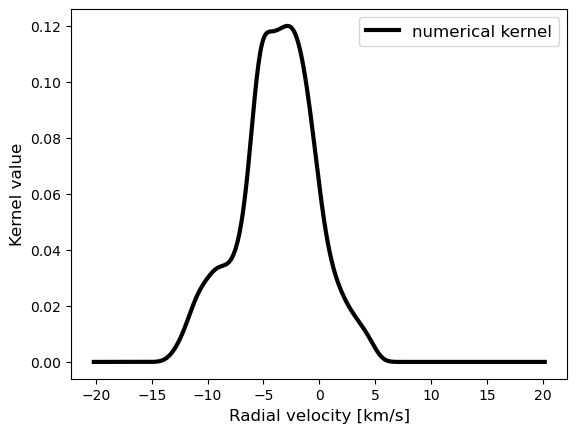

In [42]:
# Calculate the broadening kernel
dk.calculate_doppler_kernel(calculate_x_y_arrays=False)

# Plot the broadening kernel
dk.plot_doppler_kernel()

# 5. Perform a convolution with a spectrum
In this example, we convolve a template containing $\ce{CO}$ and $\ce{H2O}$ lines with the above broadening kernel. The `convolve_with_spectrum()` function simply takes the wavelength and the flux as inputs.

number of wavelength points: 46040


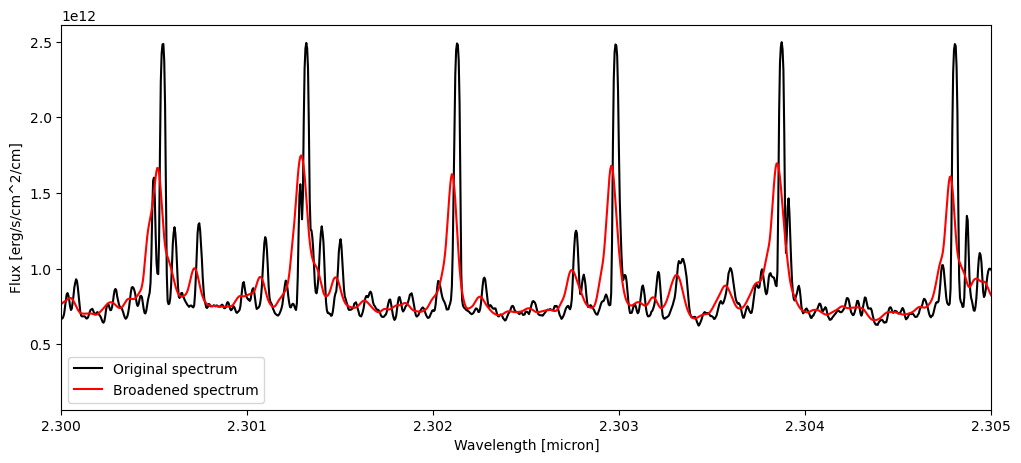

In [44]:
# Load a template spectrum
data = np.genfromtxt('template_spectrum.txt')
wlen = data[:,0] # in micron
flux = data[:,1] # in erg/s/cm^2/cm

print('number of wavelength points:', len(wlen))

# Convolve the spectrum with the previously xreated broadening kernel
broadened_flux = dk.convolve_with_spectrum(wlen, flux)

# Plot the result
plt.figure(figsize=(12,5))
plt.plot(wlen, flux, color='k', label='Original spectrum')
plt.plot(wlen, broadened_flux, color='r', label='Broadened spectrum')
plt.xlabel('Wavelength [micron]')
plt.ylabel('Flux [erg/s/cm^2/cm]')
plt.legend()
plt.xlim([2.30,2.305]) # Zoom in on a small part of the spectrum to see the line shapes
plt.show()

# 6. Calculate the cross-correlation map
In this example, we calculate the cross-correlation map associated with the velocity field and the weight mask. Internally, the `calculate_cross_correlation_map()` function does the following:
1. Calculate the velocity field and weight mask at 25 phases between $\phi = 0.2$ and $\phi = 0.8$. The function assumes the same parameter values that were passed to the `make_velocity_field()` and `make_weight_mask()` functions.
2. Calculate the broadening kernel at each of the 25 phases.
4. Convolve the input spectrum with the broadening kernel at each phase.
5. Calculate the cross-correlation between the input spectrum and the broadened spectra at each of the 25 phases.

**Parameters:**
- `velo_min`, `velo_max`: the minimum and maximum velocity values for which the cross-correlation is calculated, in km/s
- `velo_step`: the velocity step size in km/s
- `max_scale_factor_phase`: the orbital phase $\phi_{\max}$ at which the phase-dependent scale factor reaches its maximum value

Because the broadening kernel is always normalized by design (such that its integrated area is unity), we employ a phase-dependent scale factor $\alpha(\phi)$ to mimic the impact of the day-night contrast on the strength of the cross-correlation signal. Here, we parametrize it as follows:

$$
\alpha(\phi) =
\begin{cases}
\sin^2\left(\dfrac{\pi}{2}\dfrac{\phi}{\phi_{\max}}\right), & \phi \leq \phi_{\max} \\[2mm]
\cos^2\left(\dfrac{\pi}{2}\dfrac{\phi - \phi_{\max}}{1 - \phi_{\max}}\right), & \phi > \phi_{\max}
\end{cases}
$$

The axes values and the cross-correlation map are stored in `dk.CC_map_velocities`, `dk.CC_map_phases`, and `dk.CC_map`, respectively.

In [46]:
dk.calculate_cross_correlation_map(wlen, flux, velo_min=-200., velo_max=200., velo_step=0.5, max_scale_factor_phase=0.55)

Calculating Doppler-broadened spectra at each phase...
Calculating cross-correlation map between -200.0 and 200.0 km/s...
Done.


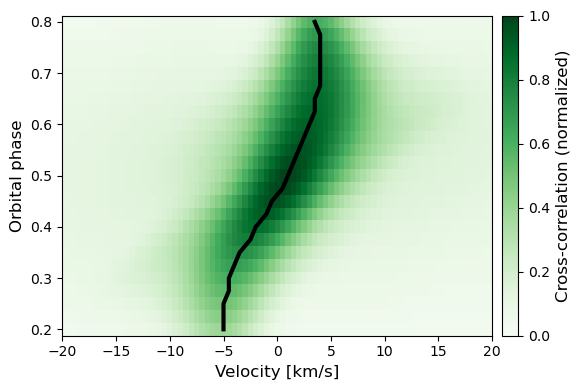

In [47]:
# Plot the generated cross-correlation map between velo_range_min and velo_range_max
dk.plot_cross_correlation_map(velo_range_min=-20., velo_range_max=20.)

# 7. Calculate the $K_\text{p}$-$v_\text{sys}$ map
We will now use the cross-correlation map from the previous example to calculate the $K_\text{p}$-$v_\text{sys}$ map. To this end, we need to select a phase range $[\phi_1, \phi_2]$ over which we want to sum the signal.

**Parameters:**
- $\phi_1$, $\phi_2$: the edges of the phase range over which the planet signal is summed, with $\phi_1 < \phi_2$ 
- `kp_min`, `kp_max`: the minimum and maximum $K_\text{p}$ values for which the map is calculated, in km/s
- `kp_step`: the $K_\text{p}$ step size in km/s
- `vsys_min`, `vsys_max`: the minimum and maximum $v_\text{sys}$ values for which the map is calculated, in km/s
- `vsys_step`: the $v_\text{sys}$ step size in km/s

The axes values and the $K_\text{p}$-$v_\text{sys}$ map are stored in `dk.kp_array`, `dk.vsys_array`, and `dk.kpvsys_map`, respectively.

The `plot_kpvsys_map()` function returns two maps:
1. The $K_\text{p}$-$v_\text{sys}$ map, whose maximum is indicated by the circular marker.
2. The cross-correlation map from the previous example, but now with the best-fit sinusoid that corresponds to the $K_\text{p}$-$v_\text{sys}$ maximum superimposed. 

In [61]:
dk.calculate_kpvsys_map(phi_1=0.25, phi_2=0.75, kp_min=-30., kp_max=30., kp_step=0.5, \
                                                vsys_min=-30, vsys_max=30, vsys_step=0.5)

Calculating Kp-vsys map between -30.0 and 30.0 km/s in Kp and between -30 and 30 km/s in vsys...
Done.


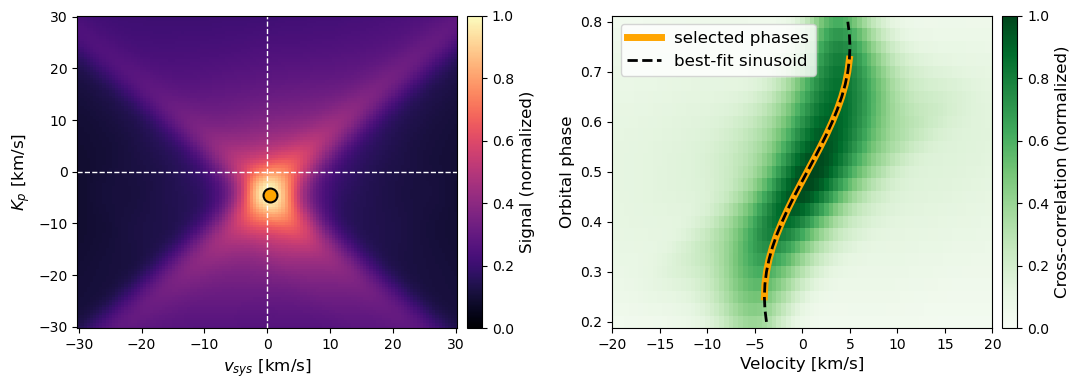

In [63]:
dk.plot_kpvsys_map()